## Actividad 3_19: Arroz
<div style="border-style:groove;border-width:thin;padding:10px">
En esta actividad vamos a utilizar las técnicas de redes neuronales y deep learning que hemos visto en clase para solucionar el problema de clasificar tipos de arroz.
    <ol>
        <li>Descarga el archivo "Rice_Image_Dataset.zip" de <a href="https://www.muratkoklu.com/datasets/vtdhnd09.php">https://www.muratkoklu.com/datasets/vtdhnd09.php</a>. Descomprime el archivo y guarda la carpeta en un lugar adecuado.</li>
        <li>Importa los datos usando las misma técnica que en la actividad de los pistachos (En este caso, 250x250 en escala de grises).</li>
        <li>Guarda las etiquetas de los datos. Debes tener un conjunto photos y otro labels que estén ordenados igual. labels debe tener números entre 0.0 y 4.0, ya que hay 5 clases de arroz.</li>
        <li>Utiliza PCA para reducir el dataset.</li>
        <li>Soluciona el ejercicio con una red neuronal. Puedes utilizar todas las técnicas que hemos aprendido.</li>
        <li>Soluciona el ejercicio usando una red convolucional.</li>
    </ol>
</div>

In [25]:
from os import listdir
from numpy import asarray
from numpy import save
import tensorflow as tf
#Deshabilitar la GPU:
#tf.config.set_visible_devices([], 'GPU')
from tensorflow import keras
from tensorflow.keras.utils import load_img
from tensorflow.keras.utils import img_to_array

folders = listdir('./Rice_Image_Dataset')
#Clase Kirmizi será la clase 0.0
#Clase Siirt será la clase 1.0


photos =  []
labels = []

In [ ]:
from os import listdir
from numpy import asarray
from numpy import save
import tensorflow as tf
from tensorflow.keras.utils import load_img
from tensorflow.keras.utils import img_to_array
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from tensorflow import keras
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR
from sklearn.metrics import classification_report
import datetime
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor



In [2]:
#2. IMPORTAMOS LOS DATOS:
for idx,folder in enumerate(folders):
    for file in listdir('./Rice_Image_Dataset/'+folder):
        #Cargamos la imagen.
        #load_img sirve para cargar las imágenes en memoria. Tiene distintos parámetros para modificar como se cargan las imágenes.
        photo = load_img('./Rice_Image_Dataset/'+folder+'/' + file, color_mode='grayscale', target_size=(100, 100)) 
        #Convertimos la imagen a un array.
        photo = img_to_array(photo)
        #Los guardamos en las listas.
        photos.append(photo)
        labels.append(float(idx))
        del photo
    print(idx)

0
1
2
3
4


In [3]:
photos = asarray(photos).astype('float32') / 255.0
photos = asarray(photos).reshape(len(photos), -1)

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(photos, labels, test_size=0.2, random_state=42)

In [5]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(X_train)


PCA()

In [6]:
import numpy as np
cumsum = np.cumsum(pca.explained_variance_ratio_)

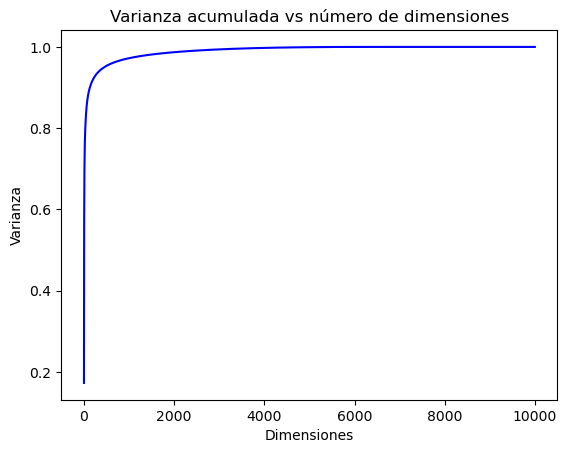

In [7]:
import matplotlib.pyplot as plt
plt.plot(range(len(cumsum)),cumsum,color='blue')
plt.title("Varianza acumulada vs número de dimensiones")
plt.xlabel('Dimensiones')
plt.ylabel('Varianza')
plt.show()

In [8]:
pca = PCA(n_components=0.95)

In [9]:
pca.fit(X_train)

PCA(n_components=0.95)

In [11]:
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

X_train_pca.shape[1]

450

In [19]:
y_train.shape

(60000,)

In [20]:
#entrenar una red neuronal con los datos transformados por PCA

model = keras.models.Sequential()
model.add(keras.layers.Dense(256, activation='relu', input_shape=(X_train_pca.shape[1],)))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(5, activation='softmax'))

/home/ciabd12/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.00001, beta_1=0.9, beta_2=0.999), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [22]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=20,
restore_best_weights=True)
X_train_pca = np.array(X_train_pca)
y_train = np.array(y_train, dtype='int32')
history = model.fit(X_train_pca, y_train, epochs=100000,validation_split = 0.1,callbacks=[early_stopping_cb])

Epoch 1/100000
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.6979 - loss: 0.9800 - val_accuracy: 0.9050 - val_loss: 0.5277
Epoch 2/100000
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.6979 - loss: 0.9800 - val_accuracy: 0.9050 - val_loss: 0.5277
Epoch 2/100000
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9282 - loss: 0.3722 - val_accuracy: 0.9398 - val_loss: 0.2683
Epoch 3/100000
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9282 - loss: 0.3722 - val_accuracy: 0.9398 - val_loss: 0.2683
Epoch 3/100000
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9487 - loss: 0.2144 - val_accuracy: 0.9570 - val_loss: 0.1751
Epoch 4/100000
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9487 - loss: 0.2144 - val_accuracy: 0.9570 - val_loss: 0.1751
Epoch 4/100000
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9609 - loss: 0.1496 - val_accuracy: 0.9652 - val_loss: 0.1314
Epoch 5/100000
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - ac

In [24]:
y_test = np.array(y_test, dtype='int32')
loss, accuracy = model.evaluate(X_test_pca, y_test)
print(f'Loss: {loss}, Accuracy: {accuracy}')

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 816us/step - accuracy: 0.9797 - loss: 0.0640
Loss: 0.06404311954975128, Accuracy: 0.9797333478927612
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 816us/step - accuracy: 0.9797 - loss: 0.0640
Loss: 0.06404311954975128, Accuracy: 0.9797333478927612


In [ ]:
model = keras.model.Sequential()
model.add(keras.layers.Conv2D())